## Cohort Analysis

In [1]:
import numpy as np 
import pandas as pd 
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


### Understand Data

#### Load data

In [2]:
data = pd.read_csv('online_retail.csv', index_col=False)

In [3]:
data.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [5]:
for x in data.columns: 
    print(x)
    print(data[x].values)

index
[     0      1      2 ... 541906 541907 541908]
InvoiceNo
['536365' '536365' '536365' ... '581587' '581587' '581587']
StockCode
['85123A' '71053' '84406B' ... '23254' '23255' '22138']
Description
['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'CHILDRENS CUTLERY DOLLY GIRL '
 'CHILDRENS CUTLERY CIRCUS PARADE' 'BAKING SET 9 PIECE RETROSPOT ']
Quantity
[6 6 8 ... 4 4 3]
InvoiceDate
['12/1/2010 8:26' '12/1/2010 8:26' '12/1/2010 8:26' ... '12/9/2011 12:50'
 '12/9/2011 12:50' '12/9/2011 12:50']
UnitPrice
[2.55 3.39 2.75 ... 4.15 4.15 4.95]
CustomerID
[17850. 17850. 17850. ... 12680. 12680. 12680.]
Country
['United Kingdom' 'United Kingdom' 'United Kingdom' ... 'France' 'France'
 'France']


### Preprocessing

In [6]:
df = data.copy()

#### Drop index col

In [7]:
df = df.drop(columns='index')

#### Check Null values

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Drop missing values

In [9]:
df= df.dropna(subset=['CustomerID'])

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### Check & Drop Duplicates

In [11]:
print(df.duplicated().sum())

5225


In [12]:
df = df.drop_duplicates()


In [13]:
print(df.duplicated().sum())

0


#### Change Datatype
- customer ID: String

In [14]:
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

In [16]:
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,401604.000000,401604,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567552,3.474064
min,-80995.000000,2010-12-01 08:26:00,0.000000
25%,2.000000,2011-04-06 15:02:00,1.250000
50%,5.000000,2011-07-29 15:40:00,1.950000
75%,12.000000,2011-10-20 11:58:30,3.750000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,250.283037,NaN,69.764035


In [17]:
df.shape

(401604, 8)

#### Quantity & Unit Price Filter
- Filter Quantity > 0 & Unit Price > 0 

In [18]:
df[df['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [19]:
df[df['StockCode'].str.len() == 1][['StockCode','Description']].value_counts()

StockCode  Description
M          Manual         460
D          Discount        77
Name: count, dtype: int64

In [20]:
df[(df['Quantity']<0) & (df['InvoiceNo'] == 'C536379')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.5,14527,United Kingdom


In [21]:
df[(df['Quantity']<0) & (df['Description'] == 'Discount')][['StockCode','Description']].value_counts()

StockCode  Description
D          Discount       77
Name: count, dtype: int64

In [25]:
df.to_csv('online_retail_preprocessed.csv', index=False)

## Cohort Analysis
- Cohort group: 고객의 첫번째 구매 날짜 

In [34]:
df1 = df.copy()

In [35]:
### Get Month
df1['InvoiceMonth'] = df1['InvoiceDate'].dt.date

#### Cohort Month: 고객의 첫 구매 날짜

In [37]:
### Get Cohort Month
df1['FirstOrderDate'] = df1.groupby('CustomerID')['InvoiceMonth'].transform('min')

### Cohort Index
- 각 코호트의 월별 활성과 고객수를 계산

In [43]:
### Change FirstOrderDate to dataframe dtype
df1['InvoiceMonth'] = pd.to_datetime(df1['InvoiceMonth'])
df1['FirstOrderDate'] = pd.to_datetime(df1['FirstOrderDate'])
# 월의 첫째날 가져오기 
df1['InvoiceMonth'] = df1['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
df1['FirstOrderDate'] = df1['FirstOrderDate'].dt.to_period('M').dt.to_timestamp()

In [48]:
df1['CohortIndex'] = (
    (df1['InvoiceMonth'].dt.year - df1['FirstOrderDate'].dt.year) * 12 +
    (df1['InvoiceMonth'].dt.month - df1['FirstOrderDate'].dt.month) #+ 1
)

In [52]:
cohort_counts = (
    df1.groupby(['FirstOrderDate', 'CohortIndex'])['CustomerID']
    .nunique() #각 그룹의 고유 고객 수(CustomerID)를 직접 계산)
    .unstack() #Reshapes the grouped data into a pivot table
)
cohort_counts


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
FirstOrderDate,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


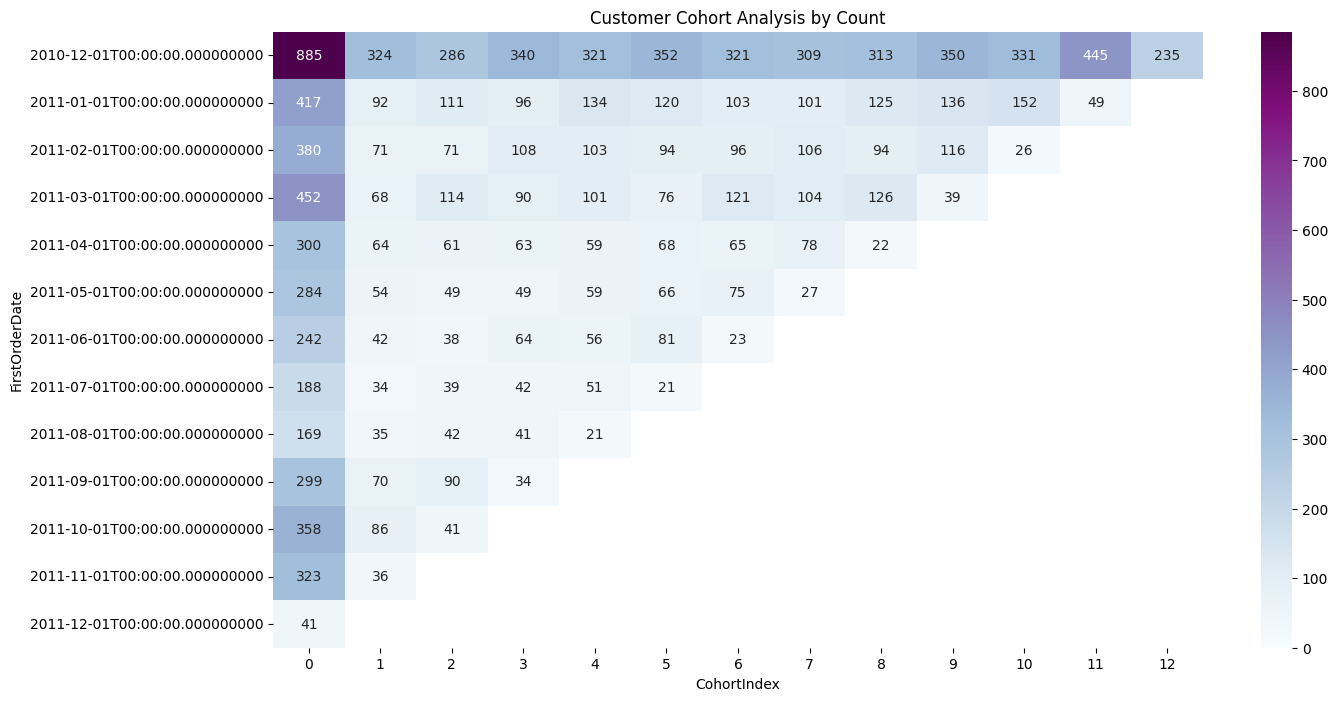

In [53]:
plt.figure(figsize=(15, 8))
plt.title('Customer Cohort Analysis by Count')
sns.heatmap(data=cohort_counts,annot = True,vmin = 0.0,fmt=".0f",cmap="BuPu")
plt.show()